In [22]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [23]:
def load_network(filepath, net_id):
    # Load adjacency, attributes, labels
    A = np.load(f"{filepath}/network_{net_id}_A.pkl", allow_pickle=True).astype(float)
    A = A - np.eye(A.shape[0])  # remove self-loops
    
    X = np.load(f"{filepath}/network_{net_id}_X.pkl", allow_pickle=True).astype(float)
    Y = np.load(f"{filepath}/network_{net_id}_Y.pkl", allow_pickle=True).astype(int)

    degrees = A.sum(axis=1)
    L = np.diag(degrees) - A
    L_sparse = csr_matrix(L)

    vals, vecs = eigsh(L_sparse, k=3, which='SM')
    u2 = vecs[:, 1]
    u3 = vecs[:, 2]

    return A, X, Y, u2, u3


In [13]:
filepath = "../data/class10/node_classification/"

networks = {}
for i in [1, 2, 3]:
    networks[i] = load_network(filepath, i)


A1, X1, Y1, u2_1, u3_1 = networks[1]
print(X1.shape, Y1.shape, u2_1.shape)

A2, X2, Y2, u2_2, u3_2 = networks[2]
print(X2.shape, Y2.shape, u2_2.shape)

A3, X3, Y3, u2_3, u3_3 = networks[3]
print(X3.shape, Y3.shape, u2_3.shape)


(200, 2) (200,) (200,)
(200, 2) (200,) (200,)
(200, 2) (200,) (200,)


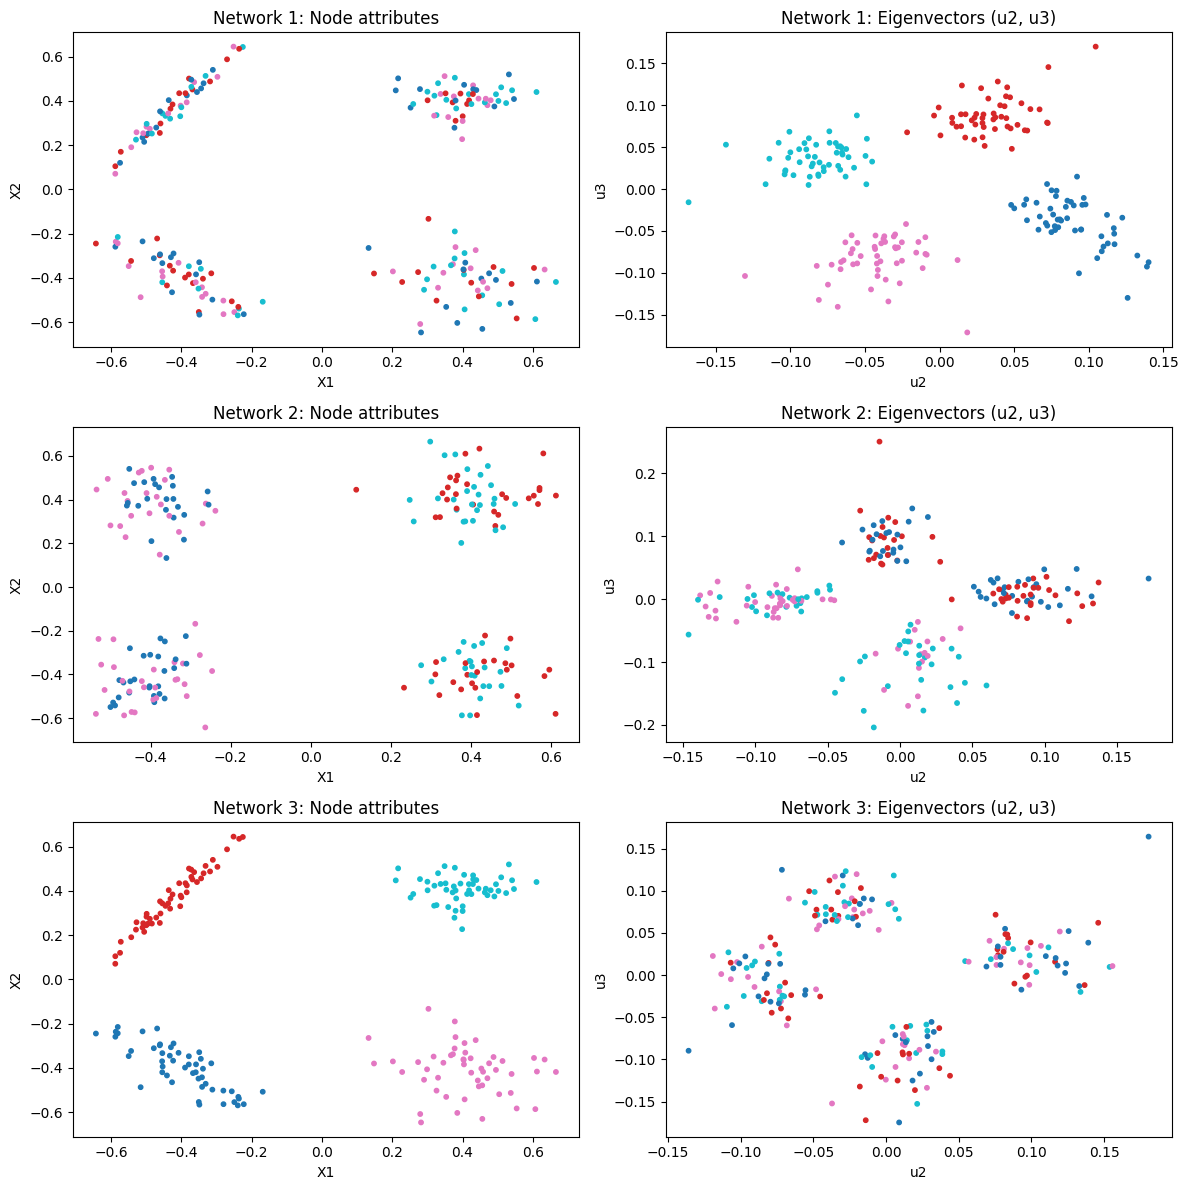

In [ ]:

plt.figure(figsize=(12, 12))

for idx in [1, 2, 3]:
    A, X, Y, u2, u3 = networks[idx]
    U = np.vstack([u2, u3]).T

    plt.subplot(3, 2, 2*(idx-1) + 1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap="tab10", s=10)
    plt.title(f"Network {idx}: Node attributes")
    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.subplot(3, 2, 2*(idx-1) + 2)
    plt.scatter(U[:,0], U[:,1], c=Y, cmap="tab10", s=10)
    plt.title(f"Network {idx}: Eigenvectors (u2, u3)")
    plt.xlabel("u2")
    plt.ylabel("u3")

plt.tight_layout()
plt.savefig("all_networks_plots.png", dpi=300)
plt.show()


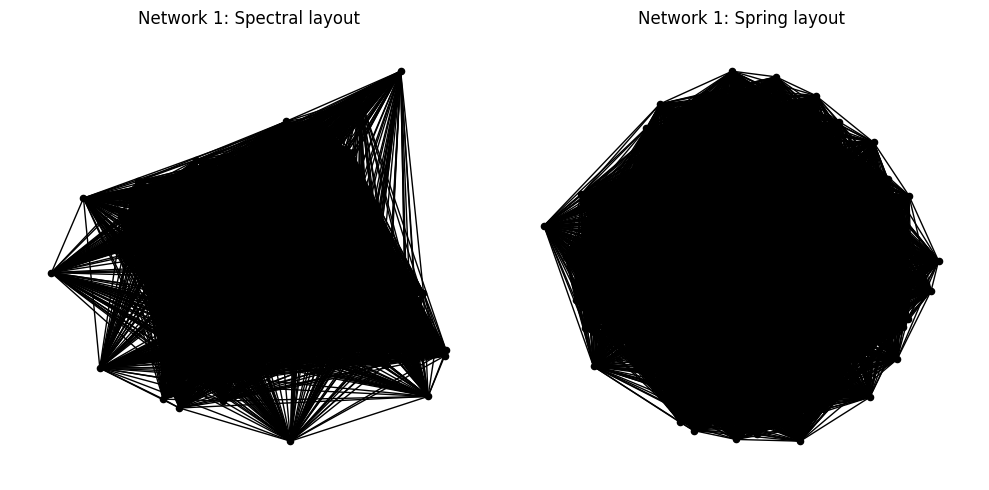

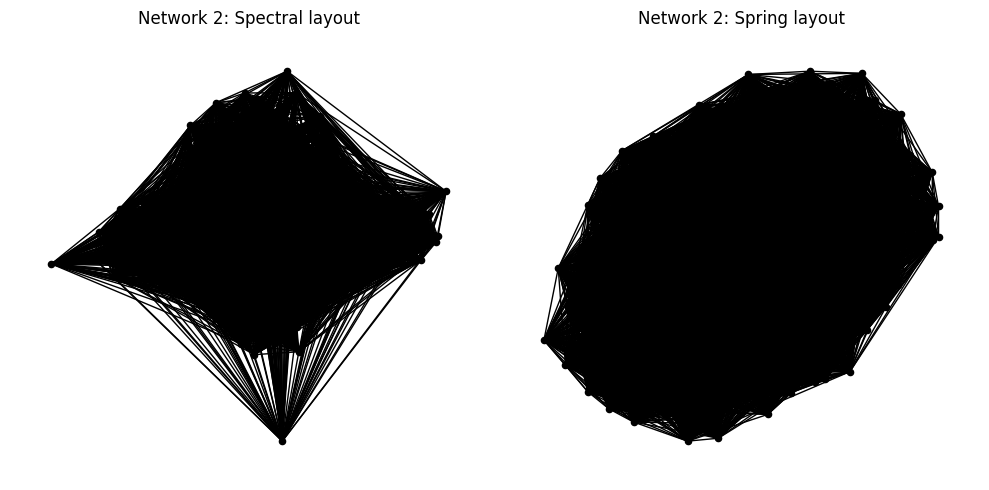

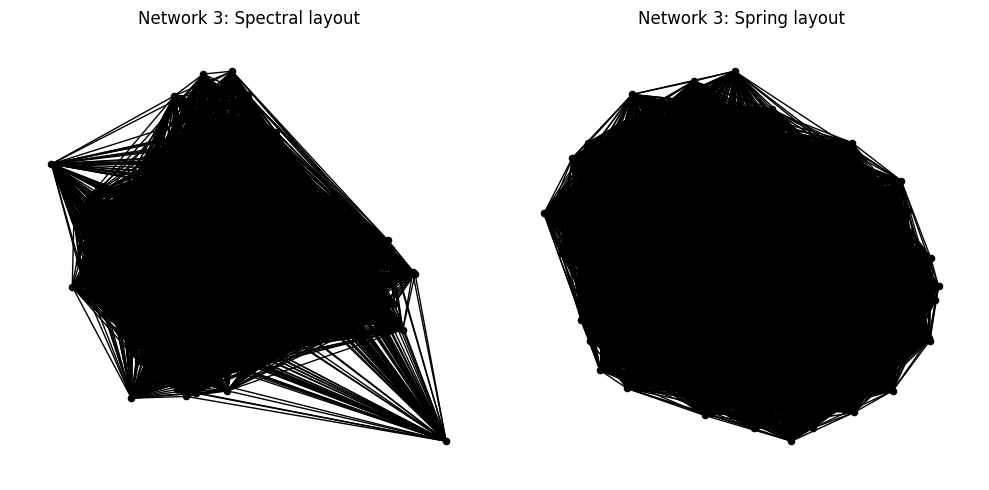

In [ ]:
def plot_network_layouts(A, net_id):
    G = nx.from_numpy_array(A)

    pos_spectral = nx.spectral_layout(G)
    pos_spring = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    nx.draw(G, pos_spectral, node_size=20, node_color="black")
    plt.title(f"Network {net_id}: Spectral layout")

    plt.subplot(1, 2, 2)
    nx.draw(G, pos_spring, node_size=20, node_color="black")
    plt.title(f"Network {net_id}: Spring layout")

    plt.tight_layout()
    plt.savefig(f"network_{net_id}_layouts.png", dpi=300)
    plt.show()


for i in [1, 2, 3]:
    A, X, Y, u2, u3 = networks[i]
    plot_network_layouts(A, i)


In [19]:
def evaluate_models(X, Y, u2, u3, net_id):
    F1 = u2.reshape(-1,1)
    F2 = u3.reshape(-1,1)
    F3 = np.vstack([u2, u3]).T
    F4 = X
    F5 = np.hstack([X, F3])

    feature_sets = [F1, F2, F3, F4, F5]
    labels = ["u2", "u3", "u2,u3", "X", "X,u2,u3"]

    idx_train, idx_test = train_test_split(
        np.arange(len(Y)), test_size=0.2, random_state=50, shuffle=True
    )

    accuracies = []

    for F in feature_sets:
        clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(F[idx_train], Y[idx_train])
        acc = clf.score(F[idx_test], Y[idx_test])
        accuracies.append(acc)

    plt.figure(figsize=(7,4))
    plt.bar(labels, accuracies, color="skyblue")
    plt.ylabel("Accuracy")
    plt.title(f"Network {net_id}: Random Forest performance")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig(f"network_{net_id}_rf_accuracy.png", dpi=300)
    plt.show()

    return accuracies


Network 1


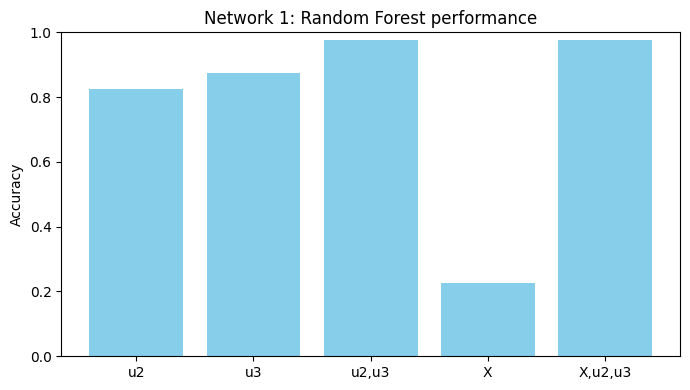

[0.825, 0.875, 0.975, 0.225, 0.975]
Network 2


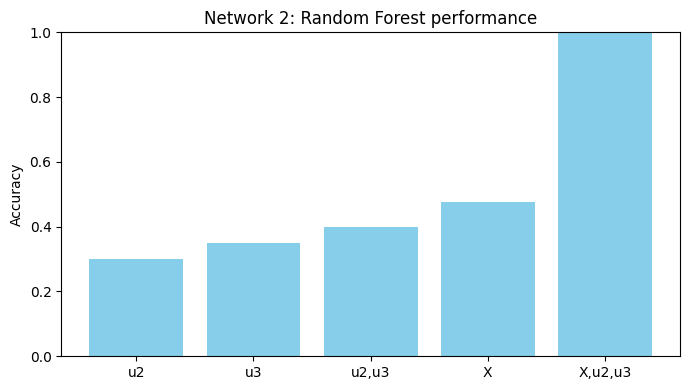

[0.3, 0.35, 0.4, 0.475, 1.0]
Network 3


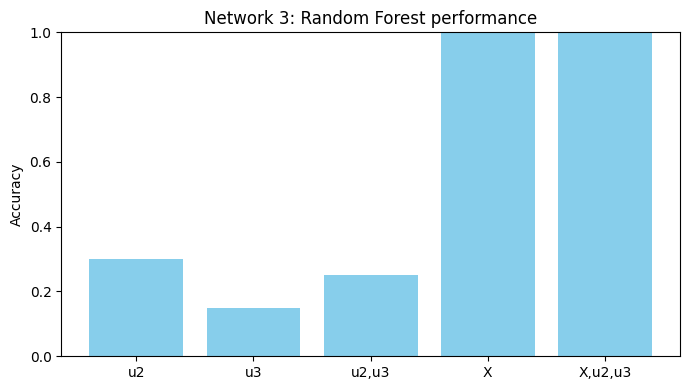

[0.3, 0.15, 0.25, 1.0, 1.0]


In [20]:
for i in [1, 2, 3]:
    A, X, Y, u2, u3 = networks[i]
    print(f"Network {i}")
    accs = evaluate_models(X, Y, u2, u3, i)
    print(accs)
